## Trabajo final de Análisis de datos: Recorridos en Ecobici

Integrantes:
- Alejandro García Peña
- Juan Francisco Nadal
- Elian Ricardo Pinzas

Docentes:
- Esp. Lic. María Carina Roldán
- Esp. Ing. Ariadna Garmendia

Carrera de Especialización en Inteligencia Artificial  
Laboratorio de Sistemas Embebidos  
Facultad de Ingeniería de la Universidad de Buenos Aires  

### Introducción

- Para este trabajo práctico se eligió el set de datos __"Recorridos en Ecobici"__.
- __Ecobici__ o __“BA Ecobici”__ es un sistema de bicicletas compartidas que funciona en la Ciudad de Buenos Aires.
-  Comenzó a funcionar en 2010 con un total de 3 estaciones y 72 bicicletas.
- En la actualidad posee más de 380 estaciones y 3600 bicicletas con presencia en 47 de los 48 barrios porteños.
- Se realizan más de 200,000 viajes por mes
- Forma de uso: el sistema requiere que el usuario se registre y pague un pase. Una vez computado el pago, se permite disponer de la bicicleta por una determinada cantidad de tiempo. Al finalizar su uso, la bicicleta debe dejarse en un punto de anclaje dentro de alguna de las estaciones habilitadas.
- El servicio se encuentra actualmente concesionado a Tembici (empresa brasileña) desde 2019 y por 10 años.


### Introducción: set de datos

Dentro del repositorio de la Ciudad de Buenos Aires (https://data.buenosaires.gob.ar/dataset/bicicletas-publicas) pueden encontrarse distintos sets de datos correspondientes a distintos años.
- El año elegido para desarrollar el presente TP es 2024. Dicho archivo es _badata_ecobici_recorridos_realizados_2024.zip_ (161 MB). Para cada registro allí contenido se describe un viaje registrado desde una estación inicial hasta una estación destino indicando, adicionalmente, otros parámetros del viaje (por ejemplo: tiempo insumido, datos de la estación de origen y destino, coordenadas de las estaciones, sexo del usuario, etc)
- Adicionalmente en el repositorio puede encontrarse otro archivo correspondiente al año 2024: _usuarios_ecobici_2024.xls_. Ese set de datos indica los usuarios que se dieron de alta durante ese año.

A los fines del presente TP, el archivo de alta de usuarios será ignorado. El desarrollo se centrará en el archivo de recorridos (_badata_ecobici_recorridos_realizados_2024.zip_.)

# Consignas

- Exploración y comprensión de los datos:
    - Cargar el dataset proporcionado y realizar un análisis exploratorio de los datos. ✅
    - Describir las características principales del dataset, incluyendo el número de observaciones, número de variables y tipos de datos. ✅
    - Identificar patrones generales y distribuciones. ✅
    - Identificar errores, outliers (anomalías), valores faltantes y su tipo (MCAR, MAR, MNAR).
- Aplicación de técnicas de visualización:
    - Utilizar los gráficos y técnicas de visualización aprendidos para ilustrar las principales características del dataset.
    - Emplear el gráfico correcto en función del tipo de variable y del análisis que se está realizando.
    - Interpretar los resultados obtenidos a partir de las visualizaciones.
    - Plantear un posible problema de ML supervisado a partir de los datos elegidos.
    - Describir el problema de clasificación o de regresión.
    - Definir la variable target.
- Preprocesamiento y limpieza del dataset:
    - Realizar una limpieza general del dataset, eliminando o corrigiendo datos inconsistentes o irrelevantes.
    - Realizar el split del dataset (ej: train y test).
    - Identificar y tratar los valores faltantes en el dataset.
    - Detectar y manejar los outliers utilizando técnicas estadísticas o visuales apropiadas.
    - Escalar/normalizar los features.
- Feature engineering:
    - Crear nuevos features en caso de ser necesario. Justificar.
    - Aplicar técnicas de conversión de variables: codificación, discretización.
    - Analizar el balance/desbalance de clases (en el caso que se trate de un problema de clasificación).
    - Proponer y aplicar mecanismos de balance en caso de ser necesario y justificar la selección.
- Reducción de dimensionalidad
    - Evaluar relaciones entre variables y realizar una selección de features con los mecanismos vistos en clase (ej: filtros).
    - Implementar la técnica de extracción de features vista en clase (PCA). Evaluar ventajas y desventajas de la reducción.

## Exploración y comprensión de los datos

### - Cargar el dataset proporcionado y realizar un análisis exploratorio de los datos.

In [29]:
import geopandas as gpd
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point

In [2]:
ecobici_df = pd.read_csv("./dataset/badata_ecobici_recorridos_realizados_2024.zip")

### - Describir las características principales del dataset, incluyendo el número de observaciones, número de variables y tipos de datos.

In [3]:
ecobici_df.head()

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
0,20428222,568,2024-01-23 18:36:00,513,308 - SAN MARTIN II,Av. San Martín 5129,-58.490739,-34.597130,2024-01-23 18:45:28,498,055 - HABANA,Gral. José Gervasio Artigas 4298 (y Habana),-58.494959,-34.586598,992557.0,FIT,MALE
1,20431744,1355,2024-01-23 22:41:20,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,2024-01-23 23:03:55,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,320782.0,FIT,FEMALE
2,20429936,0,2024-01-23 20:06:22,467,328 - SARMIENTO II,Sarmiento 2037,-58.395893,-34.605514,2024-01-23 20:06:22,6,006 - Parque Lezama,"Avenida Martin Garcia, 295",-58.369758,-34.628526,828678.0,FIT,FEMALE
3,20429976,0,2024-01-23 20:08:17,382,204 - Biarritz,Biarritz 2403,-58.477255,-34.605431,2024-01-23 20:08:17,460,133 - BEIRO Y SEGUROLA,Segurola 3194,-58.511930,-34.607500,320782.0,ICONIC,FEMALE
4,20424802,680,2024-01-23 15:18:39,137,137 - AZOPARDO Y CHILE,AZOPARDO 700,-58.367492,-34.615598,2024-01-23 15:29:59,150,150 - RODRIGO BUENO,Av. España 2200,-58.355465,-34.618755,861425.0,FIT,FEMALE


El set de datos posee 3.559.284 entradas y 17 columnas:

| Nombre | Descripción | Tipo |
|-|-|-|
|id_recorrido                   | Número identificador de recorrido                    | Categórica nominal     |
| duracion_recorrido            | Duración del recorrido                               | Numérica               |
| fecha_origen_recorrido        | Fecha en que inició el recorrido                     | Categórica / Numérica  |
| id_estacion_origen            | Número identificador de estación de origen           | Categórica nominal     |
| nombre_estacion_origen        | Nombre de estación de origen                         | Categórica nominal     |
| direccion_estacion_origen     | Dirección de estación de origen                      | Categórica nominal     |
| long_estacion_origen          | Longitud de estación de origen                       | Numérica               |
| lat_estacion_origen           | Latitud de estación de origen                        | Numérica               |
| fecha_destino_recorrido       | Fecha en que finalizó el recorrido                   | Categórica / Numérica  |
| id_estacion_destino           | Número identificador de estación de destino          | Categórica nominal     |
| nombre_estacion_destino       | Nombre de estación de destino                        | Categórica nominal     |
| direccion_estacion_destino    | Dirección de estación de destino                     | Categórica nominal     |
| long_estacion_destino         | Longitud (coordenada) de estación de destino         | Numérica               |
| lat_estacion_destino          | Latitud (coordenada) de estación de destino          | Numérica               |
| id_usuario                    | Número identificador de usuario                      | Categórica nominal     |
| modelo_bicicleta              | Nombre del modelo de la bicicleta usada en recorrido | Categórica nominal     |
| genero                        | Género del usuario del recorrido                     | Categórica binaria     |

Ajuste de variables

In [4]:
df_ecobici_numericas = ['duracion_recorrido', 'long_estacion_origen', 'lat_estacion_origen', 'long_estacion_destino', 'lat_estacion_destino']
df_ecobici_categoricas = ['id_recorrido', 'fecha_origen_recorrido', 'id_estacion_origen', 'nombre_estacion_origen', 'direccion_estacion_origen', 'fecha_destino_recorrido', 'id_estacion_destino', 'nombre_estacion_destino', 'direccion_estacion_destino', 'id_usuario', 'modelo_bicicleta', 'genero']

# Mapping para numericas y para categoricas
dtype_map = {col: 'float64'  for col in df_ecobici_numericas}
dtype_map.update({col: 'category' for col in df_ecobici_categoricas}) 

# Se aplica el mapping al dataframe
ecobici_df = ecobici_df.astype(dtype_map)

ecobici_df.dtypes

id_recorrido                  category
duracion_recorrido             float64
fecha_origen_recorrido        category
id_estacion_origen            category
nombre_estacion_origen        category
direccion_estacion_origen     category
long_estacion_origen           float64
lat_estacion_origen            float64
fecha_destino_recorrido       category
id_estacion_destino           category
nombre_estacion_destino       category
direccion_estacion_destino    category
long_estacion_destino          float64
lat_estacion_destino           float64
id_usuario                    category
modelo_bicicleta              category
genero                        category
dtype: object

### - Identificar patrones generales y distribuciones.

### - Identificar errores, outliers (anomalías), valores faltantes y su tipo (MCAR, MAR, MNAR).

## Aplicación de técnicas de visualización

### - Utilizar los gráficos y técnicas de visualización aprendidos para ilustrar las principales características del dataset. Emplear el gráfico correcto en función del tipo de variable y del análisis que se está realizando. Interpretar los resultados obtenidos a partir de las visualizaciones.

#### **Variable duracion_recorrido**

Se inicia el análisis a partir de la variable: __duracion_recorrido__, que indica cuanto dura cada recorrido.  
La primera transformación a realizar para que el análisis sea más simple será convertir la columna de segundos a minutos. Esto evitará las cuentas mentales de dividir por todo el tiempo por 60 para tratar de dimensionar en segundos algo que naturalmente se piensa en minutos

In [5]:
ecobici_df['duracion_recorrido'] = ecobici_df['duracion_recorrido'] / 60

In [6]:
# Codigo tomado de clase_02_intro_EDA_Titanic
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)  # Percentile 5-0 - Equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

In [7]:
def aclaracion_tiempo(minutos_en_flotante: float) -> str:
    minutos_fraccionarios, minutos = math.modf(minutos_en_flotante)
    return f"({int(minutos)} minutos {int(minutos_fraccionarios * 60)} segundos)"

In [8]:
print("Duración de recorridos:")

media_duracion_recorrido = ecobici_df['duracion_recorrido'].mean()
mediana_duracion_recorrido = ecobici_df['duracion_recorrido'].median()
moda_duracion_recorrido = ecobici_df['duracion_recorrido'].mode()

print(f"Media: {media_duracion_recorrido}, {aclaracion_tiempo(media_duracion_recorrido)}")
print(f"Mediana: {mediana_duracion_recorrido}, {aclaracion_tiempo(mediana_duracion_recorrido)}")
for i, moda in enumerate(ecobici_df['duracion_recorrido'].mode(), 1):
    tiempo_legible = aclaracion_tiempo(moda)
    print(f"Moda {i}: {moda} {tiempo_legible}")

# Estadística robusta
duracion_recorrido_Q1, duracion_recorrido_Q2, duracion_recorrido_Q3 = cuartiles(ecobici_df['duracion_recorrido'])

print()
print("Estadística robusta:")
print("Q1 (25%):", duracion_recorrido_Q1, aclaracion_tiempo(duracion_recorrido_Q1))
print("Q2 (Mediana, 50%):", duracion_recorrido_Q2, aclaracion_tiempo(duracion_recorrido_Q2))
print("Q3 (75%):", duracion_recorrido_Q3, aclaracion_tiempo(duracion_recorrido_Q3))

# Límites teóricos para detectar outliers
duracion_recorrido_IQR = duracion_recorrido_Q3 - duracion_recorrido_Q1
limite_inferior_para_outliers = duracion_recorrido_Q1 - 1.5 * duracion_recorrido_IQR
limite_superior_para_outliers = duracion_recorrido_Q3 + 1.5 * duracion_recorrido_IQR

print("Rango intercuartil: ", duracion_recorrido_IQR, aclaracion_tiempo(duracion_recorrido_IQR))

print()
print(f"Asímetría de la variable 'duracion_recorrido': {ecobici_df['duracion_recorrido'].skew():.4f}")
print(f"Curtosis de la variable 'duracion_recorrido': {ecobici_df['duracion_recorrido'].kurtosis():.4f}")

Duración de recorridos:
Media: 21.247112794783067, (21 minutos 14 segundos)
Mediana: 14.683333333333334, (14 minutos 41 segundos)
Moda 1: 0.03333333333333333 (0 minutos 2 segundos)

Estadística robusta:
Q1 (25%): 8.216666666666667 (8 minutos 13 segundos)
Q2 (Mediana, 50%): 14.683333333333334 (14 minutos 41 segundos)
Q3 (75%): 24.566666666666666 (24 minutos 33 segundos)
Rango intercuartil:  16.35 (16 minutos 21 segundos)

Asímetría de la variable 'duracion_recorrido': 156.2195
Curtosis de la variable 'duracion_recorrido': 30108.1573


Se trata entonces de una distribución de recorridos altamente asimétrica confirmado por el cálculo de asimetría (skewness) y los valores de Moda < Mediana < Media.

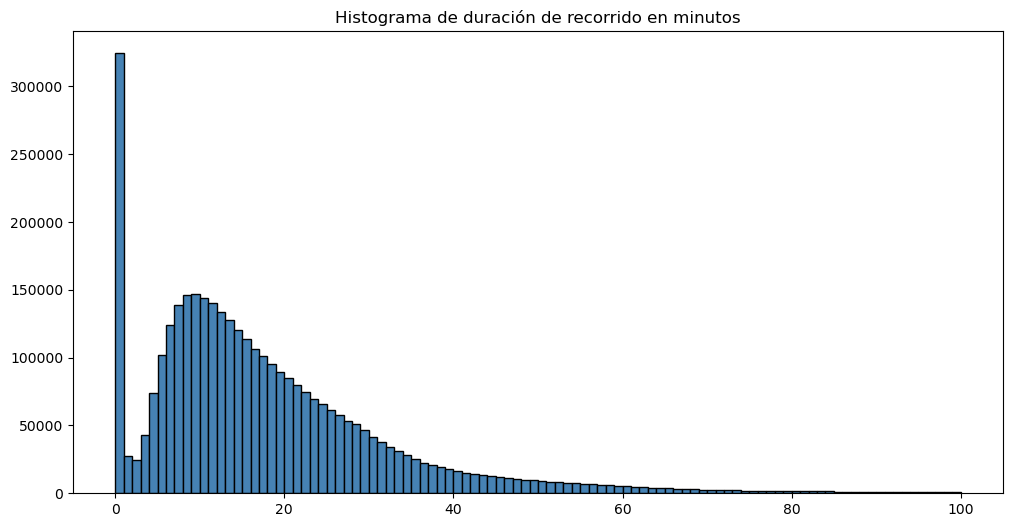

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(ecobici_df['duracion_recorrido'], bins=100, range=(0, 100), color='steelblue', edgecolor='black')
ax.set_title("Histograma de duración de recorrido en minutos")

plt.show()

Adicionalmente, se muestra la distribución de porcentajes de registros de viajes entre distintos intervalos por tiempo

In [10]:
# Intervalos y nombres
cortes = [0, 5, 10, 20, 40, 60, float('inf')]
etiquetas = ['0-5 min', '5-10 min', '10-20 min', '20-40 min', '40-60 min', 'Más de 60 min']

# Se clasifica cada viaje en su intervalo (usando la duración en minutos)
intervalos = pd.cut(ecobici_df['duracion_recorrido'], bins=cortes, labels=etiquetas, include_lowest=True)

# Cantidad total de intervalos
conteo_absoluto = intervalos.value_counts().sort_index()

# % por intervalo
tabla_porcentajes = intervalos.value_counts(normalize=True).sort_index() * 100

reporte_duracion_recorridos_df = pd.DataFrame({
    'Cantidad de Viajes': conteo_absoluto,
    'Porcentaje (%)': tabla_porcentajes
})

reporte_duracion_recorridos_df['Porcentaje (%)'] = reporte_duracion_recorridos_df['Porcentaje (%)'].round(2)

print(reporte_duracion_recorridos_df)

print()
viajes_totales = len(ecobici_df)
viajes_con_duracion_cero = (ecobici_df['duracion_recorrido'] == 0).sum()
print(f"Cantidad de viajes con duración 0: {(ecobici_df['duracion_recorrido'] == 0).sum()}, ({ viajes_con_duracion_cero * 100 / viajes_totales}%)")

                    Cantidad de Viajes  Porcentaje (%)
duracion_recorrido                                    
0-5 min                         494708           13.90
5-10 min                        658486           18.50
10-20 min                      1171111           32.90
20-40 min                       921686           25.90
40-60 min                       196482            5.52
Más de 60 min                   116811            3.28

Cantidad de viajes con duración 0: 37618, (1.0568979603763005%)


Queda claro que será necesario tratar los outliers ya que aparecen al principio de la distribución (gran cantidad de registros menores a 5 minutos, el 13,90%, incluyendo viajes de duración 0) como al final de la distribución (tiempos mayores a una hora, el 3,28%)

#### **Variable género**

In [11]:
def plot_pie(data, column, mapa_colores, ax=None, startangle=90, title=None):
    counts = data[column].value_counts()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    
    # Mapeamos los colores en el mismo orden exacto en que quedaron las categorías en 'counts'
    colores_ordenados = [mapa_colores[cat] for cat in counts.index]
    
    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=startangle,
        colors=colores_ordenados  # Usamos los colores sincronizados
    )
    ax.set_title(title if title else f'Distribución de "{column}"')
    ax.axis('equal')

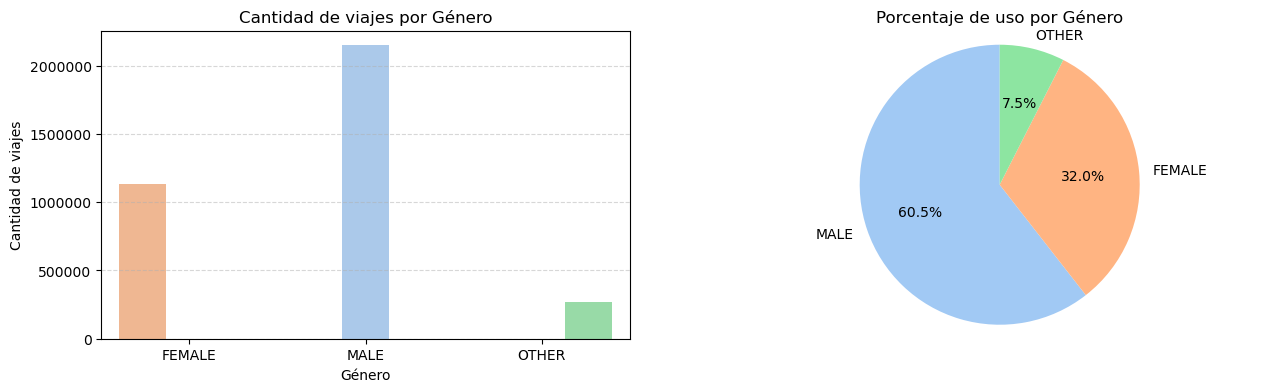

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes = axes.flatten()

paleta_base = sns.color_palette('pastel')

colores_genero = {
    'MALE':     paleta_base[0],
    'FEMALE':   paleta_base[1],
    'OTHER':    paleta_base[2]  
}

# Grafico 1: Barras
sns.countplot(
    x='genero', 
    data=ecobici_df, 
    hue='genero', 
    palette=colores_genero,
    ax=axes[0], 
    legend=False
)
axes[0].set_title('Cantidad de viajes por Género')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Cantidad de viajes')
axes[0].grid(axis='y', ls='--', alpha=0.5)
axes[0].ticklabel_format(style='plain', axis='y')

# Grafico 2: Pie chart
plot_pie(
    data=ecobici_df, 
    column='genero', 
    mapa_colores=colores_genero,
    ax=axes[1], 
    title='Porcentaje de uso por Género'
)

#### **Variable modelo de bicicleta**

In [13]:
print(ecobici_df['modelo_bicicleta'].value_counts())

modelo_bicicleta
FIT       2582443
ICONIC     976841
Name: count, dtype: int64


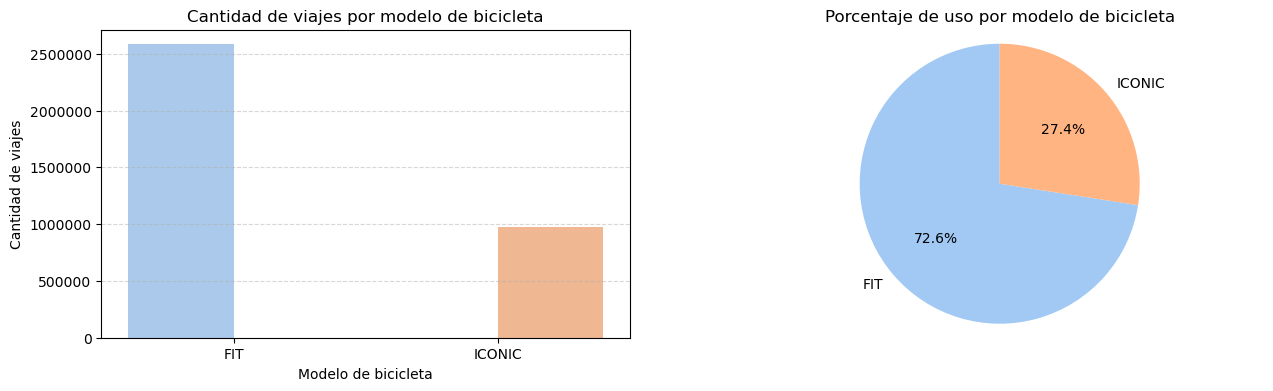

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes = axes.flatten()

paleta_base = sns.color_palette('pastel')

colores_bicicletas = {
    'FIT':     paleta_base[0],
    'ICONIC':   paleta_base[1],
}

# Grafico 1: Barras
sns.countplot(
    x='modelo_bicicleta', 
    data=ecobici_df, 
    hue='modelo_bicicleta', 
    palette=colores_bicicletas,
    ax=axes[0], 
    legend=False
)
axes[0].set_title('Cantidad de viajes por modelo de bicicleta')
axes[0].set_xlabel('Modelo de bicicleta')
axes[0].set_ylabel('Cantidad de viajes')
axes[0].grid(axis='y', ls='--', alpha=0.5)
axes[0].ticklabel_format(style='plain', axis='y')

# Grafico 2: Pie chart
plot_pie(
    data=ecobici_df, 
    column='modelo_bicicleta', 
    mapa_colores=colores_bicicletas,
    ax=axes[1], 
    title='Porcentaje de uso por modelo de bicicleta'
)

#### **Variables de estaciones de origen y destino**

In [38]:
# Se agrupan por estación de origen para tener coordenadas únicas y contar cuántos viajes salen de cada una
estaciones = (
    ecobici_df.groupby('nombre_estacion_origen')
    .agg(
        long=('long_estacion_origen', 'first'),
        lat=('lat_estacion_origen', 'first'),
        total_viajes=('id_recorrido', 'count')
    )
    .reset_index()
    .dropna() # por las dudas si hay alguna sin coordenadas
)

print(estaciones.head())

# Se crea la geometría de puntos geométricos espaciales
geometria = gpd.points_from_xy(estaciones['long'], estaciones['lat'])

# Se transforma a GeoDataFrame
geo_estaciones = gpd.GeoDataFrame(estaciones, geometry=geometria, crs="EPSG:4326")

# Se carga el mapa de los barrios de CABA
mapa_caba = gpd.read_file('./geojson/barrios.geojson')

      nombre_estacion_origen       long        lat  total_viajes
0          -CDO CUCHA CUCHA- -58.390287 -34.654474           573
1  001 - FACULTAD DE DERECHO -58.390602 -34.583749         30955
2             002 - Retiro I -58.374710 -34.592424         11051
3               003 - ADUANA -58.369129 -34.612207         18316
4           004 - Plaza Roma -58.368856 -34.603008         21168


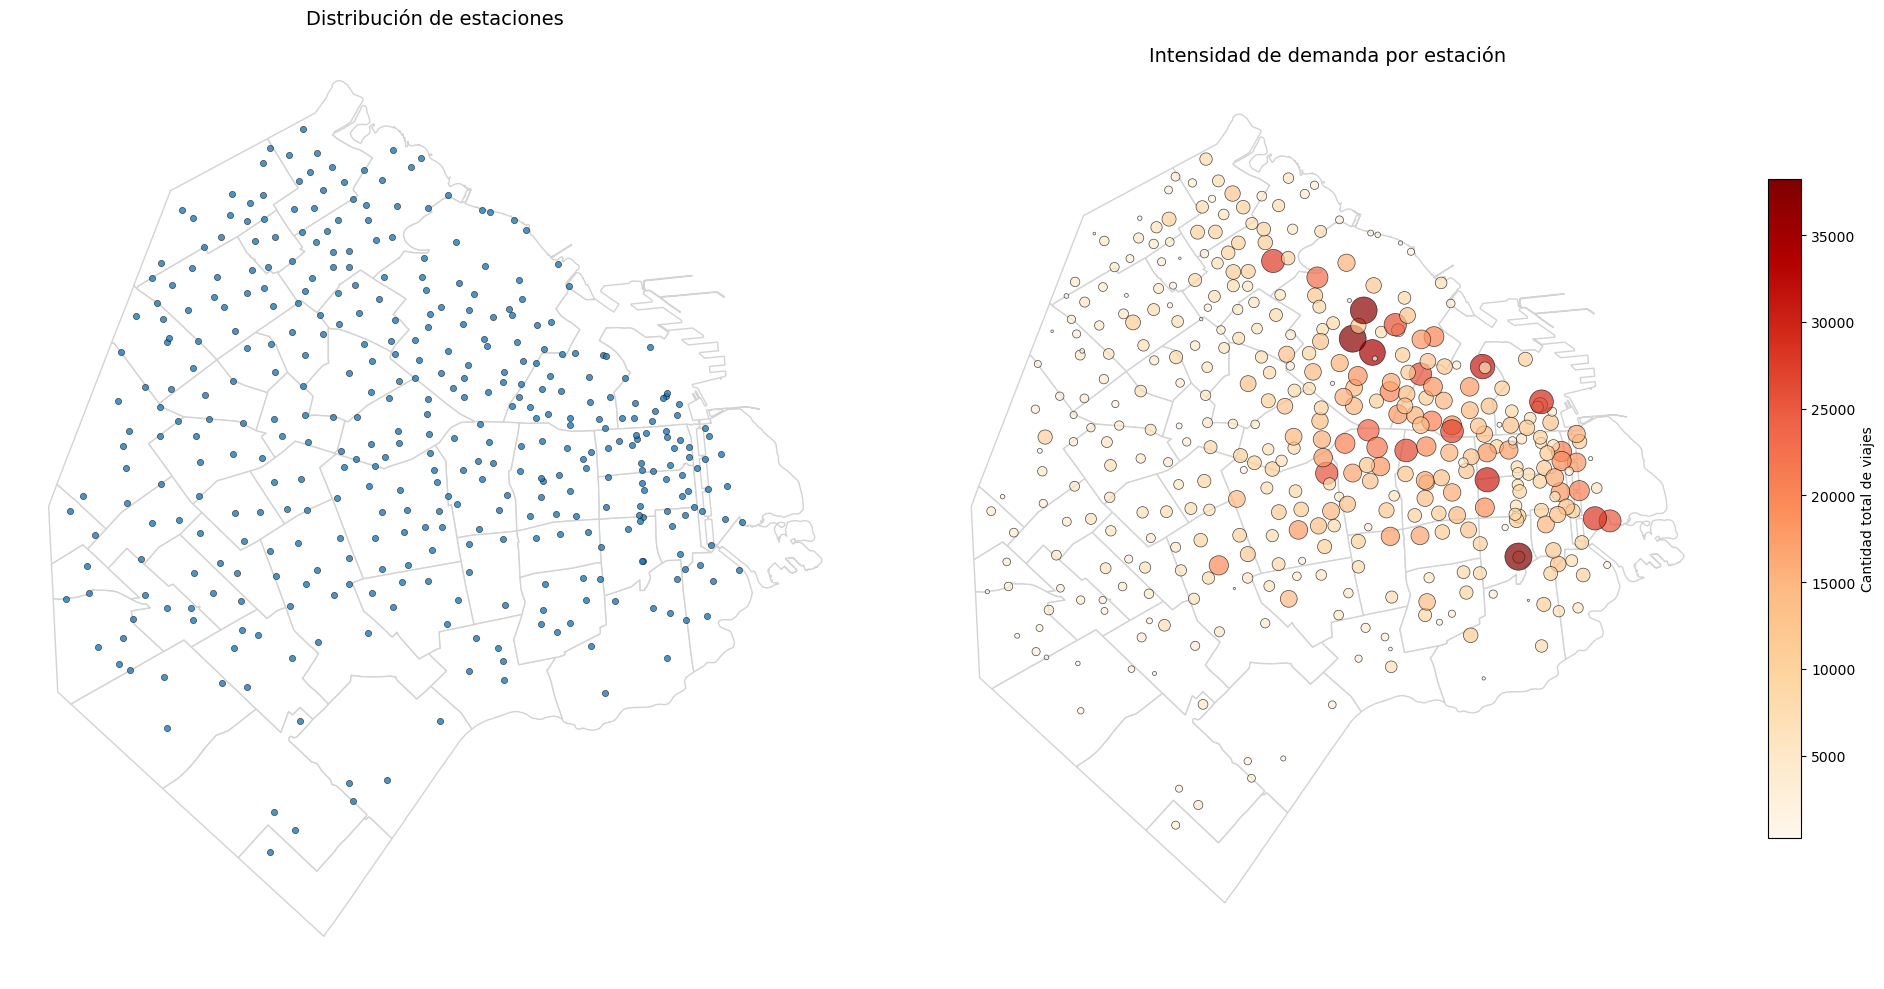

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Mapa 1: infraestructura. Se dibuja el fondo de CABA
mapa_caba.plot(ax=axes[0], color='white', edgecolor='lightgrey')

# Se dibujan las estaciones todas iguales
geo_estaciones.plot(
    ax=axes[0], 
    color='#1F77B4',
    markersize=20,   # Todos los puntos del mismo tamaño
    alpha=0.8, 
    edgecolor='black', 
    linewidth=0.4
)
axes[0].set_title('Distribución de estaciones', fontsize=14, pad=10)
axes[0].axis('off')  # Se sacan los ejes


# Mapa 2: mapa de calor (demanda de las estaciones). Se dibuja el fondo de CABA
mapa_caba.plot(ax=axes[1], color='white', edgecolor='lightgrey')

# Se dibuja el mapa de calor
geo_estaciones.plot(
    ax=axes[1], 
    column='total_viajes', 
    cmap='OrRd',       
    legend=True,       
    legend_kwds={'label': "Cantidad total de viajes", 'orientation': "vertical", 'shrink': 0.7},
    markersize=geo_estaciones['total_viajes'] / 100, # Ajustado para que no se pisen tanto
    alpha=0.7, 
    edgecolor='black', 
    linewidth=0.5
)
axes[1].set_title('Intensidad de demanda por estación', fontsize=14, pad=10)
axes[1].axis('off')  # Se sacan los ejes

plt.tight_layout()
plt.show()

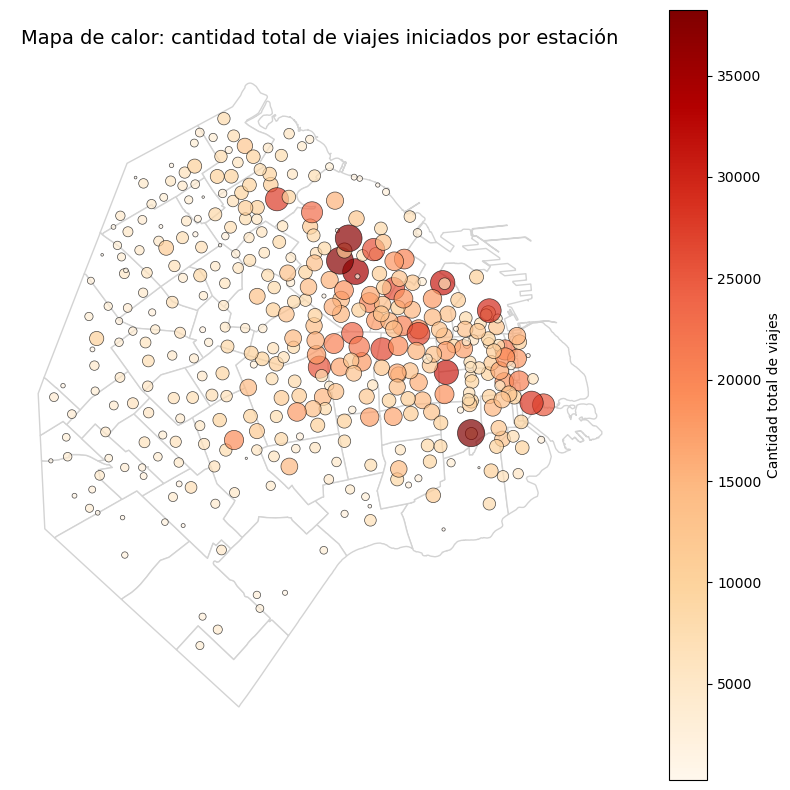

In [41]:
# Se crea el gráfico
fig, ax = plt.subplots(figsize=(10, 10))

# Se dibuja el fondo de los barrios en gris claro
mapa_caba.plot(ax=ax, color='white', edgecolor='lightgrey')

# Se dibujan las estaciones
geo_estaciones.plot(
    ax=ax, 
    column='total_viajes', 
    cmap='OrRd',       # Paleta de blanco a rojo oscuro
    legend=True,       # Muestra la barra de escala de colores
    markersize=geo_estaciones['total_viajes'] / 100, # Divisor para agrandar/achicar puntos
    legend_kwds={'label': "Cantidad total de viajes", 'orientation': "vertical"},
    alpha=0.7, 
    edgecolor='black', 
    linewidth=0.5
)

ax.set_title('Mapa de calor: cantidad total de viajes iniciados por estación', fontsize=14)
ax.axis('off') # Se saca los ejes de latitud y longitud

plt.show()

### - Plantear un posible problema de ML supervisado a partir de los datos elegidos. Describir el problema de clasificación o de regresión. Definir la variable target.

Como posible problema de ML se plantea __un problema de regresión__. La variable target será __"duración_recorrido"__, es decir, se tratará de predecir la duración de un viaje conocidas las otras variables.

## Preprocesamiento y limpieza del dataset

### - Realizar una limpieza general del dataset, eliminando o corrigiendo datos inconsistentes o irrelevantes.

### - Realizar el split del dataset (ej: train y test).


### - Identificar y tratar los valores faltantes en el dataset.

### - Detectar y manejar los outliers utilizando técnicas estadísticas o visuales apropiadas.

### - Escalar/normalizar los features.

## Feature engineering

### - Crear nuevos features en caso de ser necesario. Justificar.

### - Aplicar técnicas de conversión de variables: codificación, discretización.

### - Analizar el balance/desbalance de clases (en el caso que se trate de un problema de clasificación).

### - Proponer y aplicar mecanismos de balance en caso de ser necesario y justificar la selección.

## Reducción de dimensionalidad

### - Evaluar relaciones entre variables y realizar una selección de features con los mecanismos vistos en clase (ej: filtros).

### - Implementar la técnica de extracción de features vista en clase (PCA). Evaluar ventajas y desventajas de la reducción.